In [1]:
import numpy as np

- Simple Returns (Einfache Renditen) vs. Logarithmic Returns (logarithmische Renditen)
	- Simple Return (Einfacher Ertrag):  $$R=\left( \frac{Pneu-Palt}{Palt}\right)$$

	- Logarithmic Return (Logarithmischer Ertrag):  $$ r = \ln \left( \frac{P_{\text{neu}}}{P_{\text{alt}}} \right) $$
	- Eulerische Zahl e: $$( e = \lim_{n \to \infty} \left( 1 + \frac{1}{n} \right)^n ) $$
	- Prozentuale Veränderung der Log-Perioden: $$e^r-1$$

# Discrete Compounding

- **Annual Compounding** -> Interests accrue(erhöht) once a year at the end of the year
- Your Savings Bank offers intertests rate of **8% p.a: (stated rate)** with **annual compounding** on your savings (USD 100).
- calculate the **value** of your savings account **after one year** and the corresponding **effective annual intertest rate.**

**-> Interests are calculated and added to your savings account once at the end of the year.**

In [2]:
pv=100
r=0.08
n=1
m=1

Zinsrate aufgeteilt auf die Quartale durch 4 rechnen **8% / 4 = 2%**

In [3]:
pv=100
r=0.08
n=1
m=4

In [4]:
100*102*102*102*102

10824321600

In [5]:
fv=pv*(1+r/m)**(n*m)
fv

108.243216

In [6]:
effective_annual_rate=(fv/pv)**(1/n)-1
effective_annual_rate

0.08243215999999998

**Monthly compounding** -> interests accrue once a month at the ende of the month

In [7]:
pv=100
r=0.08
n=1
m=12

In [8]:
fv=pv*(1+r/m)**(n*m)
fv

108.29995068075098

In [9]:
effective_annual_rate=(fv/pv)**(1/n)-1
effective_annual_rate

0.08299950680750978

**infinite large number of compounding** m=99999999999999

In [10]:
pv=100
r=0.08
n=1
m=99999999999999

In [11]:
fv=pv*(1+r/m)**(n*m)
fv

109.28815610413083

In [12]:
euler=np.exp(1)
euler

np.float64(2.718281828459045)

In [13]:
fv=pv*(np.exp(n*r))
fv

np.float64(108.32870676749586)

In [14]:
pv*euler**(n*r)

np.float64(108.32870676749586)

In [15]:
effective_annual_rate=((fv/pv)**(1/n)-1) #Alternative 1
effective_annual_rate

np.float64(0.08328706767495864)

In [16]:
effective_annual_rateII=np.exp(r)#Alternative 2
effective_annual_rateII

np.float64(1.0832870676749586)

Let´s assume we observe pv and fv, how to calculate the stated rate/continuously compounded rate of 8%?

In [17]:
r=np.log(fv/pv) # inverse calculation -> use log (Alternative 1)
r

np.float64(0.08000000000000007)

In [18]:
r=np.log(effective_annual_rate+1) # inverse calculation -> use log (Alternative 2)
r

np.float64(0.08000000000000007)

** Take Home: Prices of traded Financial Instruments change (approx.) continuously.
-> intuitively, it makes a lot of sense to work with log returns**

# Log Returns

In [19]:
import pandas as pd
import numpy as np
pd.options.display.float_format='{:.6f}'.format

In [20]:
msft=pd.read_csv(r'C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Data\msft.csv', index_col='Date', parse_dates=['Date'])
msft

# column Returns represent the simple additional returns

,Price,Returns
Date,,
2014-10-01,38.880157,NaN
2014-10-02,38.761566,-0.003050
2014-10-03,39.041096,0.007212
2014-10-06,39.041096,0.000000
2014-10-07,38.566757,-0.012150
...,...,...
2021-05-24,241.744537,0.022882
2021-05-25,242.650665,0.003748
2021-05-26,242.428940,-0.000914


In [21]:
msft['log_returns']=np.log(msft.Price/msft.Price.shift()) #daily Log Returns
msft

,Price,Returns,log_returns
Date,,,
2014-10-01,38.880157,NaN,NaN
2014-10-02,38.761566,-0.003050,-0.003055
2014-10-03,39.041096,0.007212,0.007186
2014-10-06,39.041096,0.000000,0.000000
2014-10-07,38.566757,-0.012150,-0.012224
...,...,...,...
2021-05-24,241.744537,0.022882,0.022624
2021-05-25,242.650665,0.003748,0.003741
2021-05-26,242.428940,-0.000914,-0.000914


In [22]:
msft.describe()

,Price,Returns,log_returns
count,1677.000000,1676.000000,1676.000000
mean,99.129515,0.001237,0.001088
std,59.766645,0.017240,0.017233
min,34.437153,-0.147391,-0.159454
25%,48.195686,-0.006110,-0.006129
50%,82.674362,0.000962,0.000961
75%,131.331589,0.009110,0.009069
max,251.949570,0.142169,0.132929


In [23]:
mü=msft.log_returns.mean() # mean Log Return -> Reward
mü

np.float64(0.0010877096486000381)

In [24]:
sigma=msft.log_returns.std()
sigma

np.float64(0.017232778297099433)

# Simple Returns vs. Logarithmic Returns

In [25]:
import pandas as pd
import numpy as np
pd.options.display.float_format='{:.6f}'.format

In [26]:
df=pd.DataFrame(data=[100,50,90], columns=['Price'])
df

,Price
0,100
1,50
2,90


In [27]:
df['Simple_Returns']=df.Price.pct_change() #simple returns

In [28]:
df['Logarithmic_Returns']=np.log(df.Price/df.Price.shift()) #logarithmic returns

In [29]:
df

,Price,Simple_Returns,Logarithmic_Returns
0,100,NaN,NaN
1,50,-0.500000,-0.693147
2,90,0.800000,0.587787


In [30]:
periods=df.Simple_Returns.count()
periods

np.int64(2)

**The arithmetic mean of simple returns can be misleading**

In [31]:
mean_sr=df.Simple_Returns.mean()
mean_sr

np.float64(0.15000000000000002)

In [32]:
100*(1+mean_sr)**periods #wrong!!!

np.float64(132.24999999999997)

**We should use Compound Simple Returns / Geometric Mean, or even better...**

In [33]:
geo_mean=(1+df.Simple_Returns).prod()**(1/periods)-1
geo_mean

np.float64(-0.05131670194948623)

In [34]:
100*(1+ geo_mean)**periods #correct!!!

np.float64(89.99999999999999)

# ...Log Returns wich are additive over time!

In [35]:
sum_lr=df.Logarithmic_Returns.sum()
sum_lr

np.float64(-0.10536051565782623)

In [36]:
100*np.exp(sum_lr) #very correct!!!

np.float64(90.0)

In [37]:
mean_lr=df.Logarithmic_Returns.mean()
mean_lr

np.float64(-0.05268025782891311)

In [38]:
100*np.exp(mean_lr*periods) #very correct

np.float64(90.0)

**Take Home: Log Returns are additive over time. Simple Returns are not additive over time (but they can be multiplied/compounded)**

In [39]:
msft

,Price,Returns,log_returns
Date,,,
2014-10-01,38.880157,NaN,NaN
2014-10-02,38.761566,-0.003050,-0.003055
2014-10-03,39.041096,0.007212,0.007186
2014-10-06,39.041096,0.000000,0.000000
2014-10-07,38.566757,-0.012150,-0.012224
...,...,...,...
2021-05-24,241.744537,0.022882,0.022624
2021-05-25,242.650665,0.003748,0.003741
2021-05-26,242.428940,-0.000914,-0.000914


**Investment Multiple**

In [40]:
msft.Returns.add(1).prod() # compounding simple returns ('compound returns')

np.float64(6.190410313769588)

In [41]:
np.exp(msft.log_returns.sum()) # adding Log returns ('cumulative returns')

np.float64(6.190410313769357)

**Normalized Price with Base 1**


In [42]:
msft.Returns.add(1).cumprod() # compounding simple returns ('compound returns')

Date
2014-10-01        NaN
2014-10-02   0.996950
2014-10-03   1.004139
2014-10-06   1.004139
2014-10-07   0.991939
               ...   
2021-05-24   6.217684
2021-05-25   6.240990
2021-05-26   6.235287
2021-05-27   6.181238
2021-05-28   6.190410
Name: Returns, Length: 1677, dtype: float64

In [43]:
np.exp(msft.log_returns.cumsum()) # adding log returns ('cumulative returns')

Date
2014-10-01        NaN
2014-10-02   0.996950
2014-10-03   1.004139
2014-10-06   1.004139
2014-10-07   0.991939
               ...   
2021-05-24   6.217684
2021-05-25   6.240990
2021-05-26   6.235287
2021-05-27   6.181238
2021-05-28   6.190410
Name: log_returns, Length: 1677, dtype: float64

In [44]:
msft.log_returns.cumsum().apply(np.exp) # adding Log returns ('cumulative returns')

Date
2014-10-01        NaN
2014-10-02   0.996950
2014-10-03   1.004139
2014-10-06   1.004139
2014-10-07   0.991939
               ...   
2021-05-24   6.217684
2021-05-25   6.240990
2021-05-26   6.235287
2021-05-27   6.181238
2021-05-28   6.190410
Name: log_returns, Length: 1677, dtype: float64

# Compounded Annual Growth Rate **CAGR**

In [45]:
(msft.Price.iloc[-1]/msft.Price.iloc[0])**(1/((msft.index[-1]-msft.index[0]).days/365.25))-1

np.float64(0.31508347709225926)

In [46]:
trading_days_year=msft.Returns.count()/((msft.index[-1]-msft.index[0]).days/365.25)
trading_days_year

np.float64(251.81365693130397)

In [47]:
np.exp(msft.log_returns.mean()*trading_days_year)-1 # correct with mean of daily log returns!

np.float64(0.3150834770922595)

In [48]:
msft.Returns.mean()*trading_days_year #incorrect with mean of daily simple returns!

np.float64(0.31142604079915587)

In [49]:
np.exp(msft.log_returns.mean()*252)-1 # a good approximation (for US Stocks)

np.float64(0.31535005463421073)

# Performance Comparison

- **Generale Rule in Financing/Investing: Higher Rist must be rewarded with higher Returns.**
- **Wich Instrument(s) performed best/worst in the past in terms of risk & return?**

In [50]:
import pandas as pd
pd.options.display.float_format='{:.4f}'.format
import numpy as np
import matplotlib.pyplot as plt

#plt.style.available
plt.style.use('seaborn-v0_8')

In [51]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [52]:
close=pd.read_csv(r'C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Data\close.csv', index_col='Date', parse_dates=['Date'])
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,108.4067,383.6150,1.2628,1214.6000,38.8802,16804.7109
2014-10-02,107.9719,375.0720,1.2624,1214.2000,38.7616,16801.0508
2014-10-03,109.8762,359.5120,1.2671,1192.2000,39.0411,17009.6895
2014-10-04,NaN,328.8660,NaN,NaN,NaN,NaN
2014-10-05,NaN,320.5100,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2021-05-26,241.3700,39294.1992,1.2249,1901.3000,242.4289,34323.0508
2021-05-27,250.7000,38436.9688,1.2193,1895.7000,240.3275,34464.6406
2021-05-28,247.0200,35697.6055,1.2193,1902.5000,240.6841,34529.4492


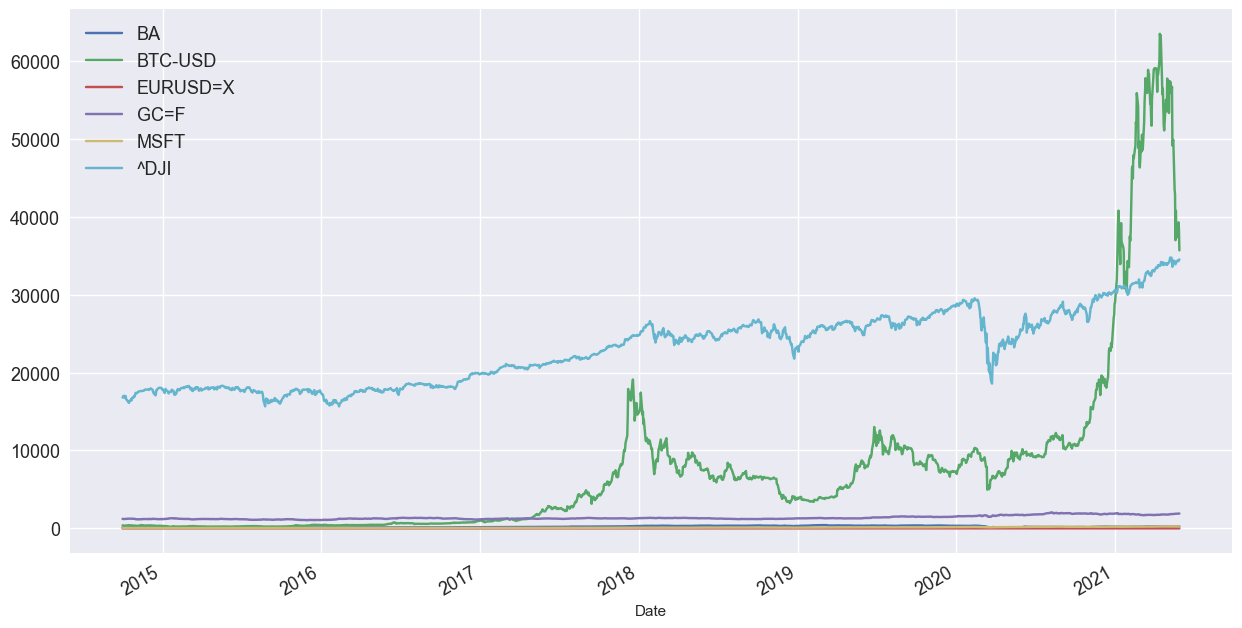

How you can see it is useless to compare the financial instruments like BA,BTC-USD and so on.


In [53]:
close.dropna().plot(figsize=(15,8),fontsize=13)
plt.legend(fontsize=13)
plt.show()
print('How you can see it is useless to compare the financial instruments like BA,BTC-USD and so on.')

In [54]:
close.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2434 entries, 2014-10-01 to 2021-05-30
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BA        1677 non-null   float64
 1   BTC-USD   2434 non-null   float64
 2   EURUSD=X  1735 non-null   float64
 3   GC=F      1674 non-null   float64
 4   MSFT      1677 non-null   float64
 5   ^DJI      1677 non-null   float64
dtypes: float64(6)
memory usage: 133.1 KB


In [55]:
np.log(close/close.shift()).info() #keep NaN

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2434 entries, 2014-10-01 to 2021-05-30
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BA        1312 non-null   float64
 1   BTC-USD   2433 non-null   float64
 2   EURUSD=X  1384 non-null   float64
 3   GC=F      1309 non-null   float64
 4   MSFT      1312 non-null   float64
 5   ^DJI      1312 non-null   float64
dtypes: float64(6)
memory usage: 133.1 KB


In [56]:
close.apply(lambda x:np.log(x.dropna()/x.dropna().shift())).info() #remove NaN

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2434 entries, 2014-10-01 to 2021-05-30
Freq: D
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BA        1676 non-null   float64
 1   BTC-USD   2433 non-null   float64
 2   EURUSD=X  1734 non-null   float64
 3   GC=F      1673 non-null   float64
 4   MSFT      1676 non-null   float64
 5   ^DJI      1676 non-null   float64
dtypes: float64(6)
memory usage: 133.1 KB


In [57]:
add = lambda x, y: x + y
print(add(3, 4))  # Ausgabe: 7


7


In [58]:
returns=close.apply(lambda x:np.log(x.dropna()/x.dropna().shift()))
returns

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,NaN,NaN,NaN,NaN,NaN,NaN
2014-10-02,-0.0040,-0.0225,-0.0003,-0.0003,-0.0031,-0.0002
2014-10-03,0.0175,-0.0424,0.0037,-0.0183,0.0072,0.0123
2014-10-04,NaN,-0.0891,NaN,NaN,NaN,NaN
2014-10-05,NaN,-0.0257,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2021-05-26,0.0026,0.0230,0.0028,0.0017,-0.0009,0.0003
2021-05-27,0.0379,-0.0221,-0.0046,-0.0029,-0.0087,0.0041
2021-05-28,-0.0148,-0.0739,0.0000,0.0036,0.0015,0.0019


In [59]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2434 entries, 2014-10-01 to 2021-05-30
Freq: D
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BA        1676 non-null   float64
 1   BTC-USD   2433 non-null   float64
 2   EURUSD=X  1734 non-null   float64
 3   GC=F      1673 non-null   float64
 4   MSFT      1676 non-null   float64
 5   ^DJI      1676 non-null   float64
dtypes: float64(6)
memory usage: 133.1 KB


In [60]:
returns.describe()

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
count,1676.0000,2433.0000,1734.0000,1673.0000,1676.0000,1676.0000
mean,0.0005,0.0019,-0.0000,0.0003,0.0011,0.0004
std,0.0263,0.0395,0.0051,0.0094,0.0172,0.0120
min,-0.2724,-0.4647,-0.0281,-0.0511,-0.1595,-0.1384
25%,-0.0091,-0.0123,-0.0031,-0.0042,-0.0061,-0.0034
50%,0.0008,0.0020,-0.0000,0.0003,0.0010,0.0007
75%,0.0105,0.0178,0.0029,0.0051,0.0091,0.0054
max,0.2177,0.2251,0.0281,0.0578,0.1329,0.1076


In [61]:
# summary=returns.agg(['mean','std'])
summary=returns.agg(['mean','std']).T
summary

,mean,std
BA,0.0005,0.0263
BTC-USD,0.0019,0.0395
EURUSD=X,-0.0000,0.0051
GC=F,0.0003,0.0094
MSFT,0.0011,0.0172
^DJI,0.0004,0.0120


In [62]:
summary.columns=['Mean','Std'] # rename column names
summary

,Mean,Std
BA,0.0005,0.0263
BTC-USD,0.0019,0.0395
EURUSD=X,-0.0000,0.0051
GC=F,0.0003,0.0094
MSFT,0.0011,0.0172
^DJI,0.0004,0.0120


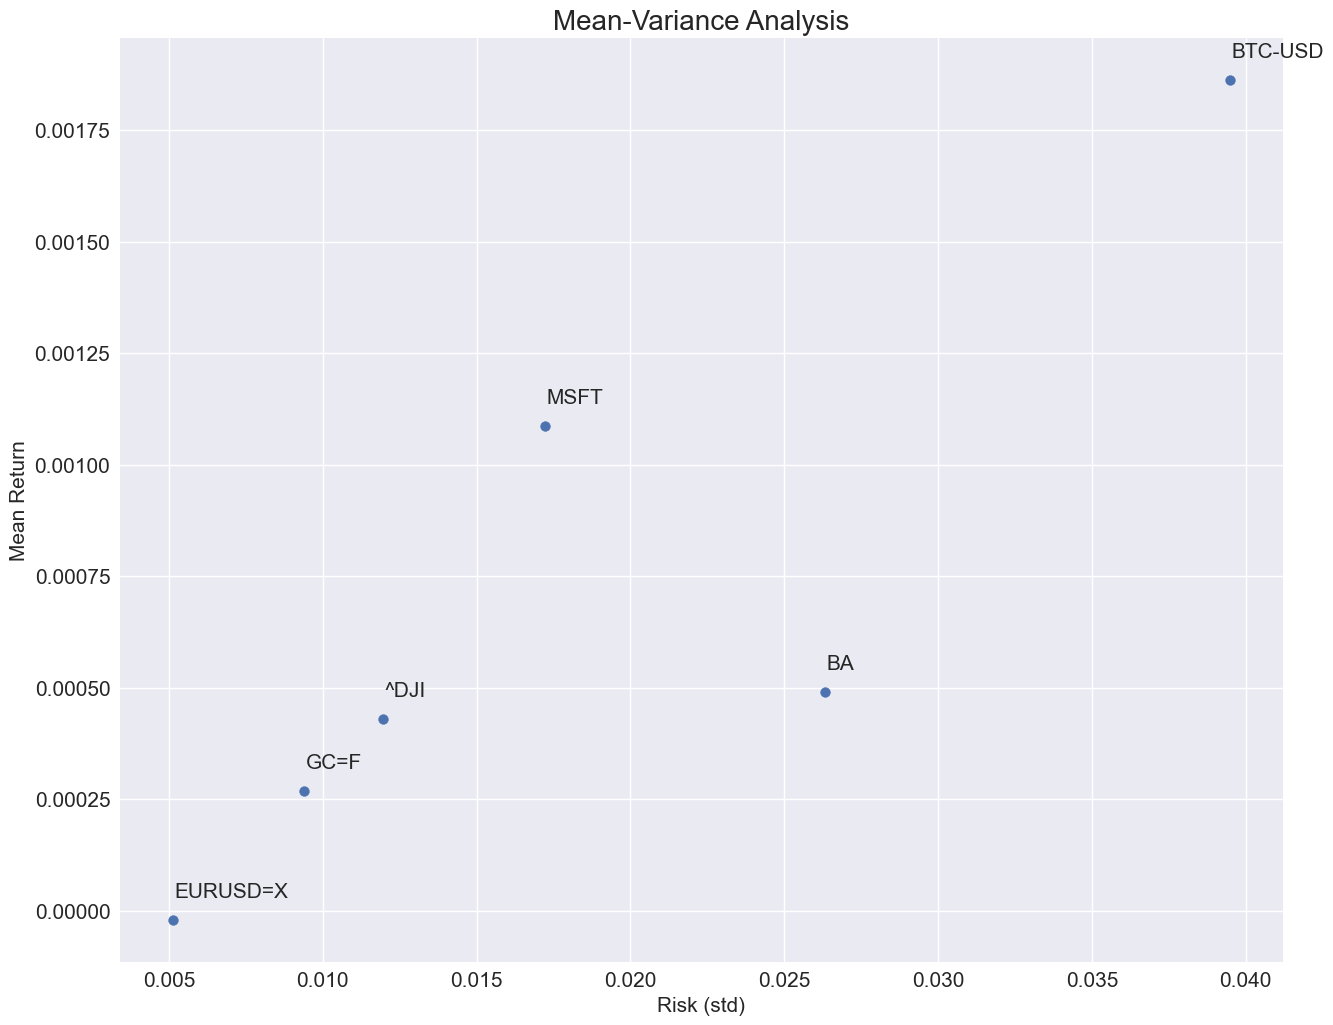

In [63]:
summary.plot(kind='scatter',x='Std',y='Mean',figsize=(15,12),s=50,fontsize=15)
for i in summary.index:
    plt.annotate(i,xy=(summary.loc[i,'Std']+0.00005,summary.loc[i,'Mean']+0.00005),size=15)
plt.xlabel('Risk (std)',fontsize=15)
plt.ylabel('Mean Return',fontsize=15)
plt.title('Mean-Variance Analysis',fontsize=20)
plt.show()

****

-> There is **no clear 'best-performer'** among [EURUSD=X, GC=F, ^DJI, MSFT] (Without further analysis. **Higher risk** is getting rewarded with **higher returns. BA underperformed**

**Take Home: Mean-Variance Analysis has one major shortcoming: It assumes that financial returns follow a Normal Distribution. That´s (typically) not True.
-> Standard Deviation of Returns underestimates the true/full risk of an investment as it fails to measure 'Tail Risks'.**

# Normality of Financial Return

- Tail Risks: beschreiben extreme negative Auswirkungen auf Finanzmärkten und Portfolios (traditionelle RIsikomodelle können diese nicht gut erfassen wegen der statistischen Verteilung)

In [64]:
import pandas as pd
pd.options.display.float_format='{:.4f}'.format
import numpy as np
import matplotlib.pyplot as plt

#plt.style.available
plt.style.use('seaborn-v0_8')

In [65]:
msft=pd.read_csv(r'C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Data\msft.csv', index_col='Date', parse_dates=['Date'])
msft

,Price,Returns
Date,,
2014-10-01,38.8802,NaN
2014-10-02,38.7616,-0.0031
2014-10-03,39.0411,0.0072
2014-10-06,39.0411,0.0000
2014-10-07,38.5668,-0.0121
...,...,...
2021-05-24,241.7445,0.0229
2021-05-25,242.6507,0.0037
2021-05-26,242.4289,-0.0009


In [66]:
msft['log_returns']=np.log(msft.Price/msft.Price.shift())
msft

,Price,Returns,log_returns
Date,,,
2014-10-01,38.8802,NaN,NaN
2014-10-02,38.7616,-0.0031,-0.0031
2014-10-03,39.0411,0.0072,0.0072
2014-10-06,39.0411,0.0000,0.0000
2014-10-07,38.5668,-0.0121,-0.0122
...,...,...,...
2021-05-24,241.7445,0.0229,0.0226
2021-05-25,242.6507,0.0037,0.0037
2021-05-26,242.4289,-0.0009,-0.0009


In [67]:
msft.describe()

,Price,Returns,log_returns
count,1677.0000,1676.0000,1676.0000
mean,99.1295,0.0012,0.0011
std,59.7666,0.0172,0.0172
min,34.4372,-0.1474,-0.1595
25%,48.1957,-0.0061,-0.0061
50%,82.6744,0.0010,0.0010
75%,131.3316,0.0091,0.0091
max,251.9496,0.1422,0.1329


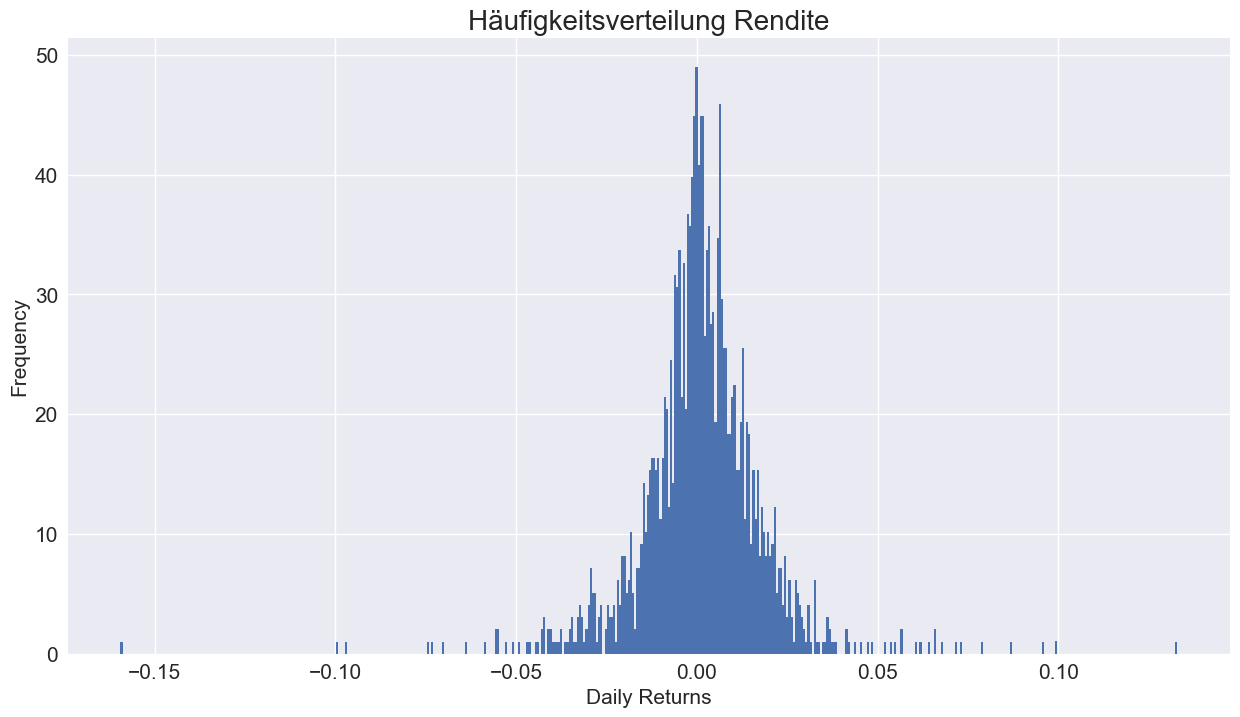

In [68]:
# Best choice for frequency distribution (Häufigkeitsverteilung) is a histogram

msft.log_returns.plot(kind='hist',figsize=(15,8),fontsize=15,bins=500,density=True)
plt.xlabel('Daily Returns',fontsize=15)
plt.ylabel('Frequency',fontsize=15)
plt.title('Häufigkeitsverteilung Rendite',fontsize=20)
plt.show()

# Do MSFT Returns follow a normal distribution?
A normally distributed random variable can be fully described by its
-   mean
-   standard deviation

Higher Central Moments are 0
- Skew= 0 (measures symmetrie around the mean)
- (Excess) Kuirtosis= 0 (positive excess Kurtosis -> more observations in the 'tails'

In [69]:
mü=msft.log_returns.mean()
mü

np.float64(0.0010877096486000381)

In [72]:
sigma=msft.log_returns.std()
sigma

np.float64(0.017232778297099433)

In [73]:
import scipy.stats as stats

In [74]:
stats.skew(msft.log_returns.dropna()) # in a Normal Distribution: skew==0

# Der Wert -0.20731 bedeutet, dass es mehr Datenpunkte auf der linken Seite gibt.

np.float64(-0.20731595831455338)

In [75]:
stats.kurtosis(msft.log_returns.dropna(),fisher=True) # in a Normal Distribution: (fisher) kurtosis==0

# Die Fischer Kurtosis von NUll zeigt an, dass die Zufallsvariable normalverteilt ist. ALlerdings haben wir hier eine klare Abweichung vom Wert 0 undzwar eine große positive Fischer Kurtosis. Es bedeutet eine höhere Konzentration von Datenpunkten um den Mittelwert und gleichzeitig auch mehr Extremwerte (positive wie negative) außerhalb des Mittelwerts.

np.float64(10.781892181750425)